This notebook is only to see the catboost regressor of the RNAseq z-score combat (withour ridge)

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import feature_selection as fs
import pickle
import regression as reg


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-27 14:39:45.466014: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-27 14:39:45.467588: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-27 14:39:45.475693: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-27 14:39:45.499014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register

In [2]:
fit=True
testing_size='40'
testing_size_f=0.40

In [3]:
#eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_train.csv")
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_z_score_Train_set_SMOTE_noise.csv")
eigth_bins.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,75.0
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,85.0
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,51.0
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,55.0


In [4]:
eigth_bins_filteres = eigth_bins#[rnaseq_genes]


In [5]:
len(eigth_bins_filteres)

230

In [6]:
del eigth_bins

In [7]:
seq_y_train_cat_a=eigth_bins_filteres["Age"]
seq_y_train_a = pd.Series(seq_y_train_cat_a)



dataset = eigth_bins_filteres.copy()
dataset["Age"]=seq_y_train_a
dataset.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,75.0
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,85.0
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,51.0
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,55.0


In [8]:
#fit=True




In [9]:
X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=testing_size_f)
x_dataset = dataset.drop(columns=["Age"])

result_df, result_metrics, ridge_model = reg.ridge_L2(X=x_dataset, y=seq_y_train_a, z=dataset["Age"], test_size=testing_size_f)


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [10]:
if fit:
    # Specify the file path where you want to save the pickle file
    file_path = f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_7_SMOTE_seq_regressor_556i_{testing_size}_RIDGE.pkl'

    # Save the ridge_model variable in the pickle file
    with open(file_path, 'wb') as f:
        pickle.dump(ridge_model, f)
else:

    # Specify the file path where the pickle file is located
    file_path = f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_7_SMOTE_seq_regressor_556i_{testing_size}_RIDGE.pkl'

    # Load the ridge_model object from the pickle file
    with open(file_path, 'rb') as f:
        ridge_model = pickle.load(f)

    # Now you can use the seq_regressor object in your code


In [11]:
result_metrics

{'Method': 'Ridge Regression',
 'MSE': 66.90612245365685,
 'RMSE': 8.179616277898178,
 'MAE': 6.160145557637911,
 'R2': 0.8686129208970639}

In [12]:
result_df

,Actual,Predicted,Group
217,86.0,71.407947,86.0
66,84.0,79.773020,84.0
9,82.0,74.528303,82.0
193,31.0,29.819077,31.0
15,69.0,74.295587,69.0
...,...,...,...
132,22.0,26.912185,22.0
182,29.0,28.002279,29.0
76,86.0,72.221559,86.0
41,72.0,79.127596,72.0


/tmp/ipykernel_108023/1211267649.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=result_df, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


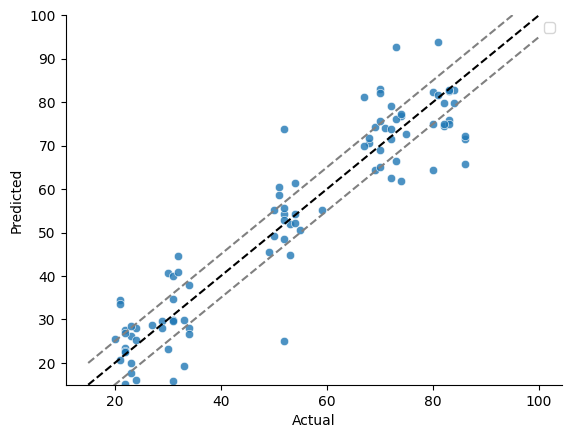

In [13]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=result_df, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_scatterplot_{testing_size}_RIDGE.png')
plt.show()

In [14]:
y_pred = result_df["Predicted"]
y_test = result_df["Actual"]

In [15]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(y_test, age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 17},
 {'label': '26-35', 'range': (26, 35), 'count': 17},
 {'label': '35-65', 'range': (35, 65), 'count': 18},
 {'label': '65-71', 'range': (65, 71), 'count': 11},
 {'label': '71-72', 'range': (71, 72), 'count': 1},
 {'label': '72-95', 'range': (72, 95), 'count': 28}]

In [16]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[ 7,  7,  0,  0,  0,  0,  3],
       [ 2,  9,  5,  0,  0,  0,  1],
       [ 1,  0, 16,  0,  0,  1,  0],
       [ 0,  0,  2,  3,  1,  5,  0],
       [ 0,  0,  0,  0,  0,  1,  0],
       [ 0,  0,  3,  2,  2, 21,  0],
       [ 0,  0,  0,  0,  0,  0,  0]])

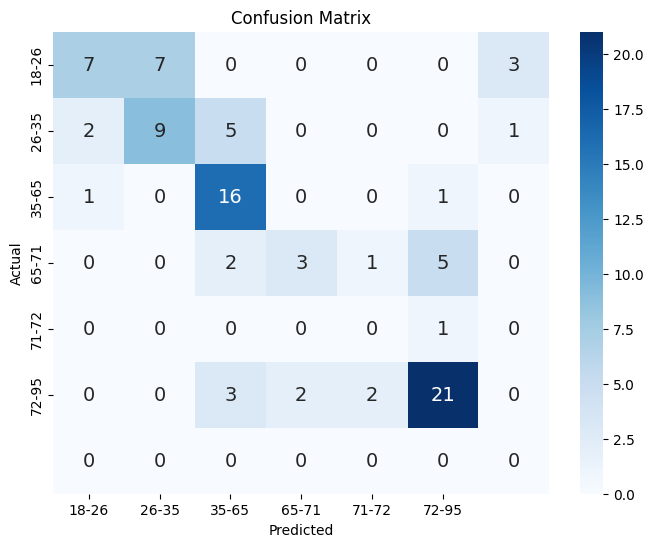

In [17]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_confusion_matrix_{testing_size}_RIDGE.png')
# save as svg
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_test_set_confusion_matrix_{testing_size}_RIDGE.svg')
plt.show()

In [18]:
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/RNAseq_Combat_z_score_Test_set.csv")
eigth_bins_test.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Status,Experiment,Age.1,Sample,Sex
0,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.024472,-0.024526,-0.023199,-0.024432,24.0,Healthy,GSE157585,24.0,SRR12604218,NaN
1,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.025252,-0.025311,-0.024447,-0.025087,18.0,Healthy,GSE167186,18.0,SRR13759023,NaN
2,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.029934,-0.029985,-0.022886,-0.029776,23.0,Healthy,GSE167186,23.0,SRR13759025,NaN
3,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.028774,-0.028772,-0.027571,-0.028812,26.4,untrained,GSE60590,26.4,SRR1555206,female
4,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.026722,-0.026784,-0.025465,-0.026577,71.0,Healthy,GSE157585,71.0,SRR12604184,NaN


In [19]:
age_ranges_list=[18, 26, 35, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(eigth_bins_test["Age"], age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-65', 'range': (35, 65), 'count': 17},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [20]:
X_test_untoached = eigth_bins_test.drop(columns=["Age"])
X_test_untoached.drop(columns=["Experiment", "Sample", "Age.1", "Status", "Sex"], inplace=True)
y_test_untoached = eigth_bins_test["Age"]
seq_z_test = eigth_bins_test["Experiment"]

In [21]:
X_test_untoached.columns

Index(['ENSG00000000003.14', 'ENSG00000000005.5', 'ENSG00000000419.12',
       'ENSG00000000457.13', 'ENSG00000000460.16', 'ENSG00000000938.12',
       'ENSG00000000971.15', 'ENSG00000001036.13', 'ENSG00000001084.11',
       'ENSG00000001167.14',
       ...
       'ENSG00000285458.1', 'ENSG00000285470.1', 'ENSG00000285471.1',
       'ENSG00000285472.1', 'ENSG00000285476.1', 'ENSG00000285480.1',
       'ENSG00000285491.1', 'ENSG00000285505.1', 'ENSG00000285508.1',
       'ENSG00000285509.1'],
      dtype='object', length=34505)

In [22]:
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

In [23]:
# Make predictions
y_pred = ridge_model.predict(X_test_untoached)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_untoached, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_untoached, 'Predicted': y_pred})
seq_mse

114.97195810228867

/tmp/ipykernel_108023/1344301980.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


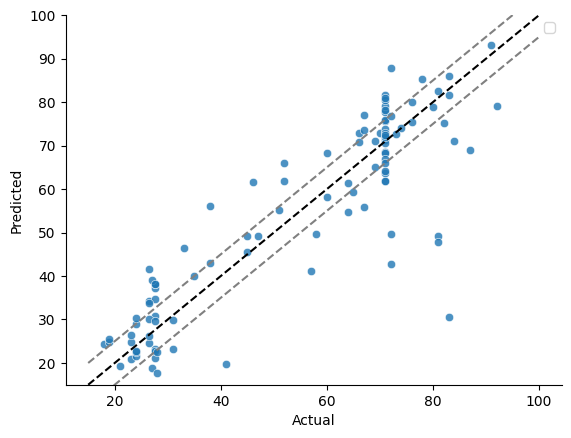

In [24]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.savefig(f'/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_7_SMOTE_seq_untouched_set_scatterplot_{testing_size}_RIDGE.png')
plt.show()

In [25]:
from importlib import reload
reload(m)

<module 'model' from '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/model.py'>

     Actual  Predicted Experiment
0      24.0  29.056820  GSE157585
1      18.0  24.422029  GSE167186
2      23.0  20.977246  GSE167186
3      26.4  41.666606   GSE60590
4      71.0  77.621266  GSE157585
..      ...        ...        ...
103    71.0  71.858171  GSE157585
104    23.0  26.527594  GSE167186
105    72.0  49.635809  GSE164471
106    71.0  64.093399  GSE157585
107    71.0  72.536318  GSE167186

[108 rows x 3 columns]


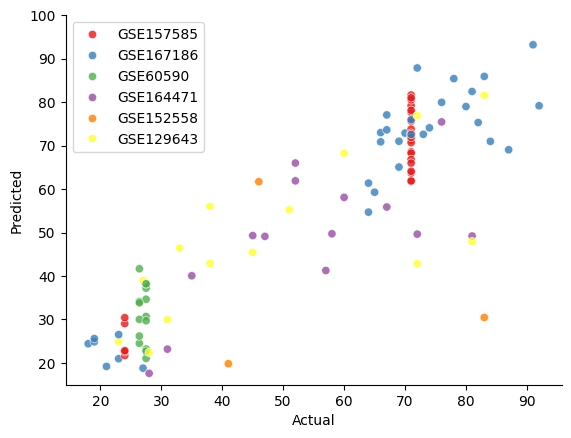

     Actual  Predicted Experiment
0      24.0  29.056820  GSE157585
1      18.0  24.422029  GSE167186
2      23.0  20.977246  GSE167186
3      26.4  41.666606   GSE60590
4      71.0  77.621266  GSE157585
..      ...        ...        ...
103    71.0  71.858171  GSE157585
104    23.0  26.527594  GSE167186
105    72.0  49.635809  GSE164471
106    71.0  64.093399  GSE157585
107    71.0  72.536318  GSE167186

[108 rows x 3 columns]


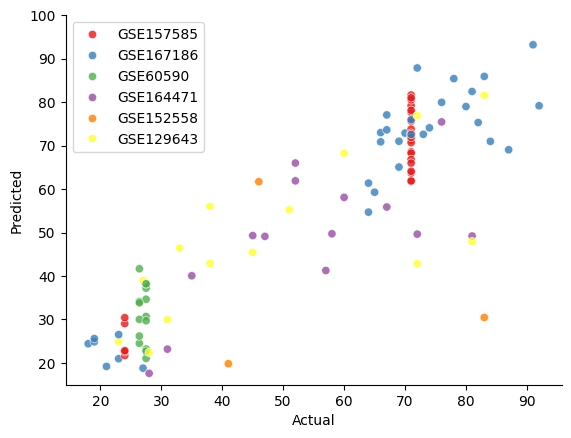

In [26]:
m.output_directory = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/"
m.plot_results(results=seq_results, labels=seq_z_test, save=True, save_output=f"ridge_regression_smote_untoached_{testing_size}.png")
m.plot_results(results=seq_results, labels=seq_z_test, save=True, save_output=f"ridge_regression_smote_untoached_{testing_size}.svg")

In [27]:
testing_size

'40'

In [28]:
c_y_test = pd.Series(y_test_untoached).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[ 9,  3,  0,  0,  0,  0,  1],
       [ 7,  8,  7,  0,  0,  0,  1],
       [ 1,  0, 14,  2,  0,  0,  0],
       [ 0,  0,  2,  3,  0,  4,  0],
       [ 0,  0,  4,  5,  2, 14,  0],
       [ 0,  1,  4,  2,  0, 14,  0],
       [ 0,  0,  0,  0,  0,  0,  0]])

In [29]:
acu = accuracy_score(c_y_test, c_y_pred)
acu

0.46296296296296297

In [30]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.3809033620725409

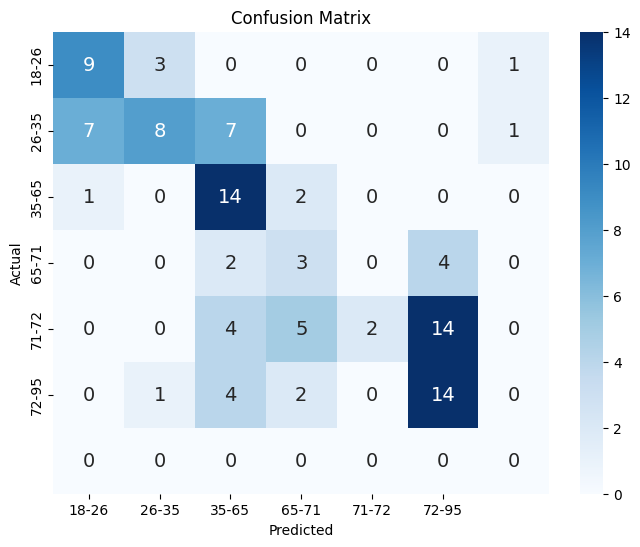

In [31]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(f"RNAseq_catboost_untoached_test_set_confusion_matrix_{testing_size}_RIDGE.png")
plt.show()

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test_untoached, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test_untoached, y_pred)

# Calculate R2
r2 = r2_score(y_test_untoached, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 114.97195810228867
RMSE: 10.722497754827868
MAE: 7.4689775240030025
R2: 0.7703578207036142


In [33]:
# Get the ridge_model.coef_ of each feature and create a DataFrame
coef_df = pd.DataFrame(ridge_model.coef_, index=X_test_untoached.columns, columns=['Coefficient'])
coef_df



,Coefficient
ENSG00000000003.14,0.121967
ENSG00000000005.5,0.054519
ENSG00000000419.12,0.084876
ENSG00000000457.13,0.042627
ENSG00000000460.16,0.002908
...,...
ENSG00000285480.1,0.035708
ENSG00000285491.1,0.063308
ENSG00000285505.1,0.060353
ENSG00000285508.1,-0.004797


In [34]:
coef_df = pd.DataFrame(ridge_model.coef_, index=X_test_untoached.columns, columns=['Coefficient'])
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df['Feature'] = coef_df.index
coef_df.reset_index(drop=True, inplace=True)
elbow_value = gtg.get_elbow_point_from_gene_rank(coef_df)
feature_imporance_df = coef_df


In [35]:
feature_imporance_path = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_7b_feature_importance_{testing_size}_RIDGE_40.csv"
feature_imporance_df.to_csv(feature_imporance_path)

In [36]:
#feature_imporance_df = pd.read_csv(f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_7b_feature_importance_{testing_size}.csv")

In [37]:
feature_imporance_df.head(50)


,Coefficient,abs_coef,Feature
0,0.121967,0.121967,ENSG00000000003.14
1,0.054519,0.054519,ENSG00000000005.5
2,0.084876,0.084876,ENSG00000000419.12
3,0.042627,0.042627,ENSG00000000457.13
4,0.002908,0.002908,ENSG00000000460.16
5,0.072843,0.072843,ENSG00000000938.12
6,-0.012397,0.012397,ENSG00000000971.15
7,-0.085086,0.085086,ENSG00000001036.13
8,-0.102701,0.102701,ENSG00000001084.11
9,-0.009736,0.009736,ENSG00000001167.14


In [38]:
len(feature_imporance_df)


34505

In [39]:
ensembl_list_file = "/home/karen/Documents/phd/Resources/ensmbl_list.csv"
ensembl_list = pd.read_csv(ensembl_list_file)

In [40]:
# remove after the point in all rows of feature_imporance_df
feature_imporance_df.index = feature_imporance_df["Feature"].str.split(".").str[0]


In [41]:
# Create a dictionary for mapping ensembl to geneSymbol
ensembl_to_gene = dict(zip(ensembl_list["ensembl"], ensembl_list["geneSymbol"]))

# Replace the index of feature_importance_df
feature_imporance_df.index = feature_imporance_df.index.map(lambda x: ensembl_to_gene.get(x, x))
feature_imporance_df.head()

,Coefficient,abs_coef,Feature
Feature,,,
TSPAN6,0.121967,0.121967,ENSG00000000003.14
TNMD,0.054519,0.054519,ENSG00000000005.5
DPM1,0.084876,0.084876,ENSG00000000419.12
SCYL3,0.042627,0.042627,ENSG00000000457.13
C1orf112,0.002908,0.002908,ENSG00000000460.16


In [42]:
X_test.rename(columns=lambda x: x.split(".")[0], inplace=True)

In [43]:
X_test = X_test.rename(columns=lambda x: ensembl_to_gene.get(x, x))


In [44]:
# Elbow and Inflexion point
rn_df = gtg.get_gene_rank(feature_imporance_path)
rn_df.to_csv(f"Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_gene_ranking_{testing_size}.csv")
top_df = gtg.get_df(feature_imporance_path)
top_df.to_csv(f"Results/feature_selection/RNAseq/feature_importance_smote_catboost_7b_top_genes_inflexion_{testing_size}.csv")

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
0.6505990661381591


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.11/site-packages/numpy/lib/polynomial.py:668: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


In [45]:
top_df

,Ensembl,coef,abs_coef,Symbol
63,63,1.272214,1.272214,ENSG00000004848.7
228,228,1.614391,1.614391,ENSG00000009307.15
355,355,2.187071,2.187071,ENSG00000015479.18
409,409,2.043561,2.043561,ENSG00000022267.16
515,515,0.849731,0.849731,ENSG00000036448.9
...,...,...,...,...
32819,32819,-0.677420,0.677420,ENSG00000273079.5
33703,33703,-0.754326,0.754326,ENSG00000278395.1
33914,33914,-0.815350,0.815350,ENSG00000280646.2
33944,33944,-0.763942,0.763942,ENSG00000281420.1


In [46]:
top_df = gtg.get_df(feature_imporance_path, inflexion=False)
top_df.to_csv(f"Results/feature_selection/RNAseq/feature_importance_smote_RIDGE_7b_top_genes_elbow_{testing_size}.csv")

0.6505990661381591


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


In [47]:
top_df

,Ensembl,coef,abs_coef,Symbol
63,63,1.272214,1.272214,ENSG00000004848.7
228,228,1.614391,1.614391,ENSG00000009307.15
355,355,2.187071,2.187071,ENSG00000015479.18
409,409,2.043561,2.043561,ENSG00000022267.16
515,515,0.849731,0.849731,ENSG00000036448.9
...,...,...,...,...
32819,32819,-0.677420,0.677420,ENSG00000273079.5
33703,33703,-0.754326,0.754326,ENSG00000278395.1
33914,33914,-0.815350,0.815350,ENSG00000280646.2
33944,33944,-0.763942,0.763942,ENSG00000281420.1


In [48]:
coef_df

,Coefficient,abs_coef,Feature
Feature,,,
TSPAN6,0.121967,0.121967,ENSG00000000003.14
TNMD,0.054519,0.054519,ENSG00000000005.5
DPM1,0.084876,0.084876,ENSG00000000419.12
SCYL3,0.042627,0.042627,ENSG00000000457.13
C1orf112,0.002908,0.002908,ENSG00000000460.16
...,...,...,...
AC021097.2,0.035708,0.035708,ENSG00000285480.1
AC135068.11,0.063308,0.063308,ENSG00000285491.1
AC010616.2,0.060353,0.060353,ENSG00000285505.1


In [49]:
coef_df = pd.DataFrame(ridge_model.coef_, index=X_test_untoached.columns, columns=['Coefficient'])
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df['Feature'] = coef_df.index
coef_df.reset_index(drop=True, inplace=True)
elbow_value = gtg.get_elbow_point_from_gene_rank(coef_df)
feature_imporance_df = coef_df

In [50]:
coef_df[coef_df['abs_coef'] > elbow_value].sort_values(by='abs_coef', ascending=False)


,Coefficient,abs_coef,Feature
24181,-8.801463,8.801463,ENSG00000234604.2
8092,6.835912,6.835912,ENSG00000143549.19
25662,6.070028,6.070028,ENSG00000239474.6
16730,5.917629,5.917629,ENSG00000198668.10
14203,5.451860,5.451860,ENSG00000181090.20
...,...,...,...
2511,0.661432,0.661432,ENSG00000101972.18
34441,0.658246,0.658246,ENSG00000285057.1
25886,0.657988,0.657988,ENSG00000240409.1
10624,0.656190,0.656190,ENSG00000163682.16


In [51]:
elbow_value

0.6505990661381591